In [2]:
#Copyright (c) 2023 John Simonis and The Ohio State University. All rights reserved.
#This code was written by John Simonis for a research project at The Ohio State University.

#This is what we use for our equations of best fit.
from pysr import PySRRegressor

#Necessary for handling symbolic outputs of pysr.
import sympy

#Let us import data into a dataframe.
import pandas as pd

#Arrays, interpolation, and analysis.
import numpy as np

#Needed for plotting.
from matplotlib import pyplot as plt

#Needed for data skew.
import scipy as sp

#This is a dictionary of a handful of customized PYSR terms, see here https://astroautomata.com/PySR/
default_pysr_params = dict(
    populations=50,
    model_selection="accuracy",
    population_size=100,
    niterations=100,
    binary_operators=["+", "*", "^"],
    unary_operators=["sin", "cos", "exp", "log", "erf", "ceil", "floor"],
    maxsize=50,
    ncycles_per_iteration=100,
    progress=False,
    procs=10,
    variable_names=["x", "y"],
)

#Control Dataset
Control_XLS = pd.ExcelFile("../Control/DessicantControlTests.xlsx")
Control_Dataframe = pd.read_excel(Control_XLS, sheet_name="Average")

#Proto Dataset
Proto_XLS = pd.ExcelFile("../Proto/ProtoTests.xlsx")
Proto_Dataframe = pd.read_excel(Proto_XLS, sheet_name="Average")

#Dep Control Dataset
DepControl_XLS = pd.ExcelFile("../Deprecated/DCTests.xlsx")
DepControl_Dataframe = pd.read_excel(
    DepControl_XLS,
    sheet_name="Average",
    names=[
        "Amps (A)",
        "Water Level (mL)",
        "Volts (V)",
        "WattHours (WH)",
        "Temp (C)",
        "Relative Humidity (%)",
        "Cumulative WattHours (WH)",
    ],
)

#Dep Proto Dataset
DepProto_XLS = pd.ExcelFile("../Deprecated/DPTests.xlsx")
DepProto_Dataframe = pd.read_excel(
    DepProto_XLS,
    sheet_name="Average",
    names=[
        "Amps (A)",
        "Water Level (mL)",
        "Volts (V)",
        "WattHours (WH)",
        "Temp (C)",
        "Relative Humidity (%)",
        "Cumulative WattHours (WH)",
    ],
)


#Control Variables
C_x = Control_Dataframe["Cumulative WattHours (WH)"].to_numpy().reshape(-1, 1)
C_y = Control_Dataframe["Water Level (mL)"].to_numpy()
C_z = Control_Dataframe["Temp (C)"].to_numpy()

#Proto Variables
P_x = Proto_Dataframe["Cumulative WattHours (WH)"].to_numpy().reshape(-1, 1)
P_y = Proto_Dataframe["Water Level (mL)"].to_numpy()
P_z = Proto_Dataframe["Temp (C)"].to_numpy()

#Dep Control Variables
DC_x = (
    pd.to_numeric(
        DepControl_Dataframe["Cumulative WattHours (WH)"].str.replace(" WH", "")
    )
    .to_numpy()
    .reshape(-1, 1)
)

DC_y = pd.to_numeric(DepControl_Dataframe["Water Level (mL)"].str.replace(" mL", "")).to_numpy()
DC_z = pd.to_numeric(DepControl_Dataframe["Temp (C)"].str.replace(" C", "")).to_numpy()

#Dep Proto Variables
DP_x = (
    pd.to_numeric(
        DepProto_Dataframe["Cumulative WattHours (WH)"].str.replace(" WH", "")
    )
    .to_numpy()
    .reshape(-1, 1)
)

DP_y = pd.to_numeric(DepProto_Dataframe["Water Level (mL)"].str.replace(" mL", "")).to_numpy()
DP_z = pd.to_numeric(DepProto_Dataframe["Temp (C)"].str.replace(" C", "")).to_numpy()

def analysis(data):
    data_headers = ["Vertical Power", "Vertical Temp", "Vertical Amp", "Vertical Water"]
    for i in range(0, 4):
        print(data_headers[i], "STDDEV:", np.std(data[i]))
        print(data_headers[i], "MEDIAN:", np.median(data[i]))
        print(data_headers[i], "SKEW:", sp.stats.skew(data[i]), "\n")

Detected Jupyter notebook. Loading juliacall extension. Set `PYSR_AUTOLOAD_EXTENSIONS=no` to disable.


## Dessicant Wheel Control
The Control Water Harvester utilizes a desiccant wheel design, leveraging a heat lamp to dry out pockets of desiccant and a fan to circulate heated air through the silica gel desiccant.

In [3]:
#Pass in the fitting parameters
Control_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
Control_Equations.fit(C_x, C_y)

C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:872: FutureWarning: variable_names is a data dependant parameter so should be passed when fit is called. Ignoring parameter; please pass variable_names during the call to fit instead.
  warnings.warn(
C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:1231: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:65: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(


Compiling Julia backend...


[ Info: Started!



Expressions evaluated per second: 2.870e+05
Head worker occupation: 24.6%
Progress: 964 / 5000 total iterations (19.280%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           9.003e+01  1.594e+01  y = -0.74386
2           1.757e+01  1.634e+00  y = exp(2.05)
3           1.614e-01  4.690e+00  y = x₀ * 0.16432
4           1.445e-01  1.110e-01  y = 0.16304 * ceil(x₀)
5           1.022e-01  3.459e-01  y = 0.15642 * (x₀ + 3.1248)
6           1.013e-01  9.192e-03  y = 0.15631 * floor(x₀ + 3.6629)
7           9.596e-02  5.411e-02  y = log(floor(1.1773 ^ x₀) + x₀)
8           7.945e-02  1.888e-01  y = log((x₀ * 0.53473) + (1.1777 ^ x₀))
9           7.802e-02  1.819e-02  y = log((0.63991 * x₀) + floor(1.1777 ^ x₀))
10          7.568e-02  3.047e-02  y = log(((x₀ * 0.048867) * x₀) + (1.1771 ^ x₀))
11          6.815e-02  1.047e-01  y = log(ceil(1.01 ^ x₀) * (1.1047 ^ (1.509 * x₀)))
12

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                         0.49925312   
	1         1.388259                                     exp(2.0500283)   
	2         4.689684                                    x0 * 0.16431591   
	3         0.111044                              0.16303821 * ceil(x0)   
	4         0.345900                      0.15641771 * (x0 + 3.1247764)   
	5         0.009949                 floor(x0 + 3.6466272) * 0.15633985   
	6         0.373534        (1.0138196 + (x0 * 0.09370803)) ^ 1.2023351   
	7         0.051202          ((x0 * 0.09550014) + erf(x0)) ^ 1.1939186   
	8         0.014355  (erf(x0 * 0.2636569) + (x0 * 0.09550014)) ^ 1....   
	9         0.028408  ((x0 * 0.095520146) + erf(floor(x0 ^ 0.4240418...   
	10        0.020136  (((x0 * 0.07896315) + 0.15603659) + erf(x0 * 0...   
	11        0.272259  log((0.5316514 * x0) + (1.1776663 ^ (x0 + cos(...   
	12        0.001442  log((1.1776876 ^ (x0 + cos(ceil(x0) ^ 0.555297...   
	13        0.028413  log((0.63225204 * x0) + floor(1.1776663 ^ (x0 ...   
	14        0.268434  log((0.55689543 * x0) + (1.1777555 ^ ((2.07943...   
	15        0.005574  log((0.55689543 * x0) + (1.1777555 ^ ((2.07943...   
	16        0.020075  log(floor(1.1777456 ^ (x0 + (exp(0.75444937) *...   
	17        0.001906  log((x0 * 0.6137796) + floor(1.1776435 ^ (x0 +...   
	18        0.002144  log((x0 * 0.6098857) + (floor(1.1777385 ^ (x0 ...   
	19        0.053399  log((0.63225204 * x0) + floor(1.1777456 ^ (x0 ...   
	20        0.128132  log((x0 * 0.5188681) + (1.1776434 ^ (cos(x0 ^ ...   
	21        0.009268  log((x0 * 0.5459055) + (1.1776657 ^ (cos(x0 ^ ...   
	22        0.008862  log((x0 * 0.5459055) + (1.1776657 ^ (sin(cos(x...   
	23        0.001728  log((x0 * 0.5504564) + (1.1776634 ^ (sin(cos(x...   
	24        0.011239  log((x0 * 0.5372038) + (1.1778009 ^ (sin(cos(x...   
	25        0.001442  log((x0 * 0.5372038) + (1.1778009 ^ (sin(cos(x...   
	26        0.003923  log((x0 * 0.5504564) + (1.1778009 ^ (sin(cos((...   
	27        0.001455  log((1.1778009 ^ ((erf(erf(x0)) * cos(x0 ^ cos...   
	28        0.002521  log((1.1778009 ^ ((erf(erf(x0)) * cos(x0 ^ cos...   
	29        0.003321  log((1.1778009 ^ ((cos(sin(exp(-0.88487184))) ...   
	30        0.002121  log((1.1778009 ^ ((cos(erf(1.1085955) * -0.689...   
	31  >>>>  0.000227  log((1.1778009 ^ ((cos(sin(erf(1.1085955) * -0...   
	
	         loss  complexity  
	0   70.410240           1  
	1   17.568020           2  
	2    0.161443           3  
	3    0.144475           4  
	4    0.102228           5  
	5    0.101216           6  
	6    0.069667           7  
	7    0.066190           8  
	8    0.064316          10  
	9    0.062515          11  
	10   0.061269          12  
	11   0.046666          13  
	12   0.046598          14  
	13   0.045293          15  
	14   0.034630          16  
	15   0.034437          17  
	16   0.033753          18  
	17   0.033689          19  
	18   0.033617          20  
	19   0.031869          21  
	20   0.028036          22  
	21   0.027777          23  
	22   0.027532          24  
	23   0.027485          25  
	24   0.027178          26  
	25   0.027138          27  
	26   0.027032          28  
	27   0.026954          30  
	28   0.026886          31  
	29   0.026708          33  
	30   0.026651          34  
	31   0.026645          35  
]

Vertical Power STDDEV: 0.003055499438317472
Vertical Power MEDIAN: 0.5133333333333333
Vertical Power SKEW: 0.1908440289314235 

Vertical Temp STDDEV: 2.9918445133812783
Vertical Temp MEDIAN: 27.08
Vertical Temp SKEW: 0.00830511957701228 

Vertical Amp STDDEV: 0.023454447576336378
Vertical Amp MEDIAN: 7.713333333333334
Vertical Amp SKEW: -0.10235233214597493 

Vertical Water STDDEV: 4.191422343549114
Vertical Water MEDIAN: 7.333333333333333
Vertical Water SKEW: 0.13485310695774946 

\log{\left(1.18^{x_{0} + 0.841 \cos{\left(x_{0}^{0.974} + 0.155 \right)} + \cos{\left(\left\lceil{x_{0}}\right\rceil^{0.553} \right)} \left\lfloor{e^{\operatorname{erf}{\left(x_{0} \right)}}}\right\rfloor} + 0.550 x_{0} \right)}


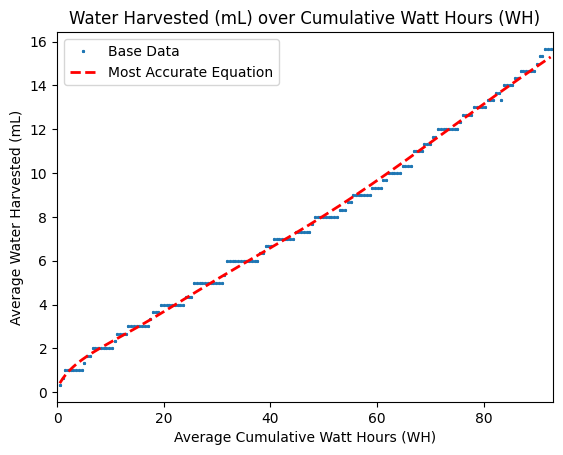

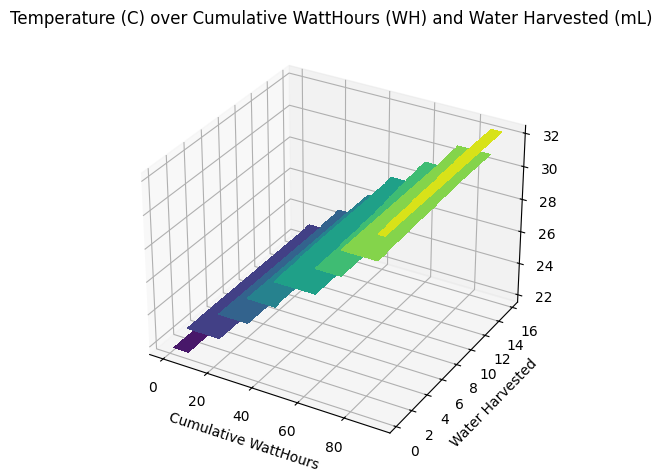

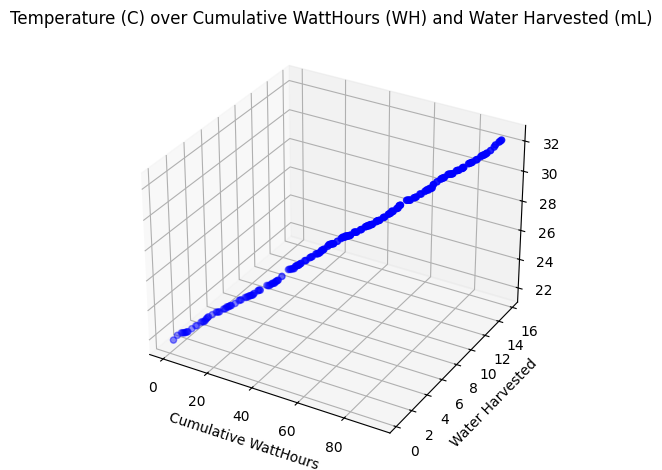

In [57]:
#Basic scatter plot
plt.plot(
    C_x,
    C_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = Control_Equations.equations_.query(
    f"loss < {2 * Control_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    C_x,
    Control_Equations.predict(C_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over Cumulative Watt Hours (WH)")
plt.xlabel("Average Cumulative Watt Hours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 93])
analysis(
    [
        Control_Dataframe["WattHours (WH)"].to_numpy(),
        C_z,
        Control_Dataframe["Amps (A)"].to_numpy(),
        C_y,
    ]
)
print(Control_Equations.latex())

#3D scatterplot and contour plot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours")
plt.ylabel("Water Harvested")
fig.tight_layout()
C_X, C_Y = np.meshgrid(C_x,C_y)
C_Z = sp.interpolate.griddata(np.column_stack((C_x.reshape(-1,1),C_y)), C_z, (C_X, C_Y), method = "nearest")
plt.contourf(C_x.reshape(-1),C_y,C_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(C_x,C_y,C_z)

# NiTi Prototype
The NiTi prototype employs a straightforward gantry system, powered by a high torque stepper motor. A T8 leadscrew is incorporated for a simple mechanical advantage to apply stress to the NiTi wires.

In [24]:
#Run PySR
Proto_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
Proto_Equations.fit(P_x, P_y)

C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:872: FutureWarning: variable_names is a data dependant parameter so should be passed when fit is called. Ignoring parameter; please pass variable_names during the call to fit instead.
  warnings.warn(
C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:1231: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:65: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Start


Expressions evaluated per second: 3.300e+05
Head worker occupation: 26.0%
Progress: 988 / 5000 total iterations (19.760%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           1.989e+01  1.594e+01  y = 1.2548
2           6.921e+00  1.055e+00  y = exp(1.5721)
3           6.963e-02  4.599e+00  y = 0.18877 * x₀
4           6.273e-02  1.043e-01  y = 0.18593 * ceil(x₀)
5           4.099e-02  4.254e-01  y = (x₀ ^ 0.91051) * 0.26013
6           4.099e-02  6.694e-05  y = (x₀ ^ sin(1.1466)) * 0.25934
7           3.855e-02  6.136e-02  y = ((-0.0006189 * x₀) + 0.21219) * x₀
8           3.854e-02  3.384e-04  y = x₀ * ((-0.00061783 * floor(x₀)) + 0.21186)
10          3.439e-02  5.689e-02  y = ((ceil(x₀ * 0.046915) * -0.0079431) + 0.20747) * x₀
15          3.421e-02  1.041e-03  y = ((-0.00064828 * (x₀ + (cos(erf(-0.97754) * x₀) * 2.8436)))...
                                   + 0.21359

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                          1.2547851   
	1         1.055371                                     exp(1.5720825)   
	2         4.599244                                    0.18877153 * x0   
	3         0.104332                              0.18592541 * ceil(x0)   
	4         0.425458                     (x0 ^ 0.91104823) * 0.25962543   
	5         0.000009                   (x0 ^ sin(1.146575)) * 0.2593432   
	6         0.061360          ((-0.00061890105 * x0) + 0.21219453) * x0   
	7         0.000339   x0 * ((-0.00061782985 * floor(x0)) + 0.21186078)   
	8         0.078777  x0 * (0.2034023 + (ceil(x0 * -0.047843024) * 0...   
	9         0.000016  x0 * (0.2034023 + sin(ceil(x0 * -0.047843024) ...   
	10        0.049510  x0 * ((ceil(-0.04784211 * (x0 + -1.0691392)) *...   
	11        0.017450  ((0.010736867 * floor(floor(x0 ^ 0.5184098) * ...   
	12        0.025659  (0.21307312 + (-0.00064546464 * (x0 + (sin(flo...   
	13        0.004763  (sin(0.21545403) + (((6.9286733 * sin(0.883913...   
	14        0.012876  (sin(0.21545403) + ((ceil(6.9286733 * sin(0.88...   
	15        0.000009  (sin(0.21545403) + sin((ceil(6.9286733 * sin(0...   
	16        0.002088  (sin(0.21545403) + (ceil((6.9286733 * sin(0.88...   
	17        0.007521  (0.21284269 + (((6.9307594 * cos(sin(-1.012908...   
	18        0.000967  (((ceil(6.9307594 * cos(erf(-1.0129082) * (flo...   
	19        0.079429  (0.21396977 + (((cos(sin(-1.0426092) * (cos(x0...   
	20        0.012249  (0.21396977 + (((cos(sin(1.0372851) * (cos(x0 ...   
	21        0.007478  (0.21396977 + (((cos(sin(1.0372851) * (sin(cos...   
	22        0.012339  (0.21386403 + (((cos(sin(1.0372851) * (cos(x0 ...   
	23  >>>>  0.009581  (0.21386403 + (((cos(sin(1.0372851) * (erf(cos...   
	
	         loss  complexity  
	0   19.885422           1  
	1    6.921388           2  
	2    0.069625           3  
	3    0.062727           4  
	4    0.040990           5  
	5    0.040990           6  
	6    0.038550           7  
	7    0.038537           8  
	8    0.032920          10  
	9    0.032919          11  
	10   0.031329          12  
	11   0.030787          13  
	12   0.029247          15  
	13   0.029108          16  
	14   0.028736          17  
	15   0.028735          18  
	16   0.028676          19  
	17   0.028247          21  
	18   0.028220          22  
	19   0.026065          23  
	20   0.025748          24  
	21   0.025556          25  
	22   0.025243          26  
	23   0.025002          27  
]

Vertical Power STDDEV: 0.2785496658115589
Vertical Power MEDIAN: 0.27
Vertical Power SKEW: 0.0014724439344308453 

Vertical Temp STDDEV: 0.14768078479453892
Vertical Temp MEDIAN: 23.511666666666663
Vertical Temp SKEW: -0.04108905149599962 

Vertical Amp STDDEV: 4.179428089587817
Vertical Amp MEDIAN: 4.045
Vertical Amp SKEW: 0.0012824667441691305 

Vertical Water STDDEV: 2.6305658218736663
Vertical Water MEDIAN: 5.0
Vertical Water SKEW: -0.11995470090320919 

x_{0} \left(- 0.000675 x_{0} - 0.00581 \cos{\left(0.861 \operatorname{erf}{\left(\cos{\left(0.632 x_{0} \right)} \right)} + 0.861 \left\lfloor{x_{0} - 0.855}\right\rfloor \right)} + 0.214\right)


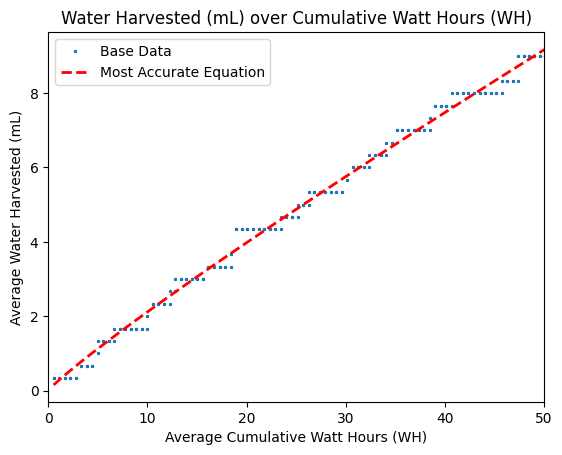

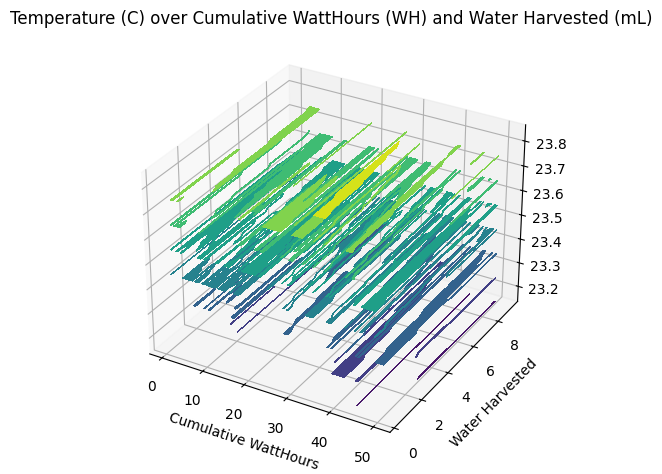

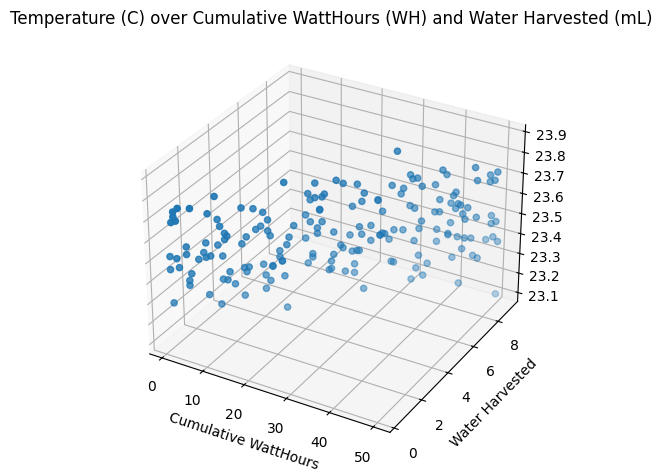

In [44]:
#Basic scatter plot
plt.plot(
    P_x,
    P_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = Proto_Equations.equations_.query(
    f"loss < {2 * Proto_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    P_x,
    Proto_Equations.predict(P_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over Cumulative Watt Hours (WH)")
plt.xlabel("Average Cumulative Watt Hours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 50])
analysis(
    [
        Proto_Dataframe["WattHours (WH)"].to_numpy(),
        P_z,
        Proto_Dataframe["Amps (A)"].to_numpy(),
        P_y,
    ]
)
print(Proto_Equations.latex())

#3D scatterplot and contour plot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours", loc="left")
plt.ylabel("Water Harvested")
fig.tight_layout()
P_X, P_Y = np.meshgrid(P_x,P_y)
P_Z = sp.interpolate.griddata(np.column_stack((P_x.reshape(-1,1),P_y)), P_z, (P_X, P_Y), method = "nearest")
plt.contourf(P_x.reshape(-1),P_y,P_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(P_x,P_y,P_z)

# Deprecated Designs
The Peltier device is first and then the first NiTi prototype is second.

In [29]:
#Run PySR
DepControl_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
DepControl_Equations.fit(DC_x,DC_y)

C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:872: FutureWarning: variable_names is a data dependant parameter so should be passed when fit is called. Ignoring parameter; please pass variable_names during the call to fit instead.
  warnings.warn(
C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:1231: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:65: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Start


Expressions evaluated per second: 2.330e+05
Head worker occupation: 25.3%
Progress: 768 / 5000 total iterations (15.360%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
1           7.343e+00  1.594e+01  y = 0.20699
2           1.611e-01  3.819e+00  y = log(x₀)
4           1.332e-01  9.525e-02  y = floor(x₀ ^ 0.39167)
5           1.325e-01  5.047e-03  y = floor(log(1.5906 * x₀))
6           1.028e-01  2.539e-01  y = erf(0.046453 * x₀) * 3.6508
7           7.773e-02  2.793e-01  y = log(x₀) * erf(x₀ * 0.096899)
8           7.721e-02  6.757e-03  y = log(ceil(x₀)) * erf(x₀ * 0.092942)
9           7.697e-02  3.109e-03  y = log(ceil(x₀)) * erf(ceil(x₀) * 0.088388)
10          4.656e-02  5.027e-01  y = erf(x₀ * 0.096573) * ceil(log(x₀ * 0.58247))
11          2.872e-02  4.833e-01  y = erf(0.090377 * x₀) * ceil(log(ceil(0.5825 * x₀)))
12          2.551e-02  1.183e-01  y = erf(0.090377 * 

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                          1.6808199   
	1         2.615573                                            log(x0)   
	2         0.095255                             floor(x0 ^ 0.39167115)   
	3         0.373273                     -0.80518323 + (x0 ^ 0.4193608)   
	4         0.001429               -0.8928715 + (ceil(x0) ^ 0.42346036)   
	5         0.163612                     log(x0) * erf(x0 * 0.09689925)   
	6         0.118589           (x0 ^ 0.35788953) * erf(0.09754315 * x0)   
	7         1.472392       ceil(x0 ^ 0.31048214) * erf(0.07658366 * x0)   
	8         0.037956  ceil(x0 ^ 0.3103865) * erf(ceil(x0) * 0.073246...   
	9         0.046140  erf(x0 * 0.07963146) * ceil(log(ceil(x0 ^ 0.84...   
	10        0.103940  erf(0.0796135 * x0) * ceil(log(2.0855308 + (0....   
	11        0.019832  erf(ceil(x0) * 0.075955436) * ceil(log(2.10822...   
	12        0.082548  ceil(x0 ^ 0.31040242) * erf((x0 + sin(0.492396...   
	13        0.033452  ceil(x0 ^ 0.31051198) * erf((x0 + sin(floor(x0...   
	14        0.058921  ceil(x0 ^ 0.31042278) * erf(floor(x0 + sin(flo...   
	15        0.000441  ceil(x0 ^ 0.31042278) * erf(floor(x0 + sin(flo...   
	16        0.039236  ceil(x0 ^ 0.31054503) * erf((floor(x0) + sin(e...   
	17        0.006934  ceil(x0 ^ 0.31054503) * erf((floor(x0) + sin(e...   
	18        0.034365  erf(0.07895427 * (sin((x0 * 0.09340997) * x0) ...   
	19        0.057600  erf(0.07929846 * (x0 + sin((x0 * erf(0.0834023...   
	20        0.067197  erf(0.07929846 * (x0 + sin(ceil((floor(x0) * 0...   
	21        0.000002  erf(0.07929846 * (x0 + sin(ceil((floor(x0 + 0....   
	22        0.005218  erf(0.07959634 * (sin((x0 + sin(x0 * (sin(cos(...   
	23        0.002695  erf(0.07959634 * (sin((x0 + sin(x0 * (sin(sin(...   
	24        0.003294  erf(0.07959634 * (sin(((x0 + sin(erf(0.0749546...   
	25        0.000076  erf(0.07959634 * (sin(((x0 + sin(erf(0.0749546...   
	26        0.000225  erf((0.07959634 * (sin(((x0 + sin((sin(sin(cos...   
	27  >>>>  0.000181  erf((sin((x0 * erf(0.08206192)) * floor(x0 + s...   
	
	        loss  complexity  
	0   2.203171           1  
	1   0.161109           2  
	2   0.133163           4  
	3   0.091679           5  
	4   0.091549           6  
	5   0.077731           7  
	6   0.069039           8  
	7   0.015836           9  
	8   0.015246          10  
	9   0.014559          11  
	10  0.013121          12  
	11  0.012864          13  
	12  0.011844          14  
	13  0.011455          15  
	14  0.010799          16  
	15  0.010795          17  
	16  0.010379          18  
	17  0.010308          19  
	18  0.009959          20  
	19  0.009402          21  
	20  0.008791          22  
	21  0.008791          24  
	22  0.008476          31  
	23  0.008453          32  
	24  0.008425          33  
	25  0.008424          34  
	26  0.008419          37  
	27  0.008403          47  
]

Vertical Power STDDEV: 0.003346364051814961
Vertical Power MEDIAN: 0.25
Vertical Power SKEW: -2.2203703729531203 

Vertical Temp STDDEV: 0.10611890293381486
Vertical Temp MEDIAN: 22.8
Vertical Temp SKEW: -0.10926708348002251 

Vertical Amp STDDEV: 0.027706118013451422
Vertical Amp MEDIAN: 3.73
Vertical Amp SKEW: 0.06975514771080801 

Vertical Water STDDEV: 1.0906223289417172
Vertical Water MEDIAN: 3.0
Vertical Water SKEW: -0.7987799534398714 

\left\lceil{\log{\left(0.526 x_{0} + 2.07 \right)}}\right\rceil \operatorname{erf}{\left(0.0790 x_{0} + 0.0790 \sin{\left(0.0924 x_{0} \left\lfloor{x_{0} + \sin{\left(x_{0} \cos{\left(\cos{\left(\operatorname{erf}{\left(\cos{\left(\left(e^{x_{0}} + 2.07\right) \left\lceil{\cos{\left(2 e^{\left\lceil{x_{0}}\right\rceil + 1} \right)}}\right\rceil \right)} \right)} \right)} \right)} \right)}}\right\rfloor \right)} \right)}


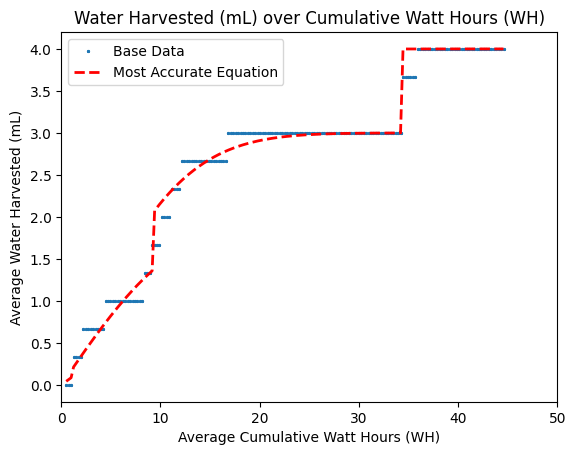

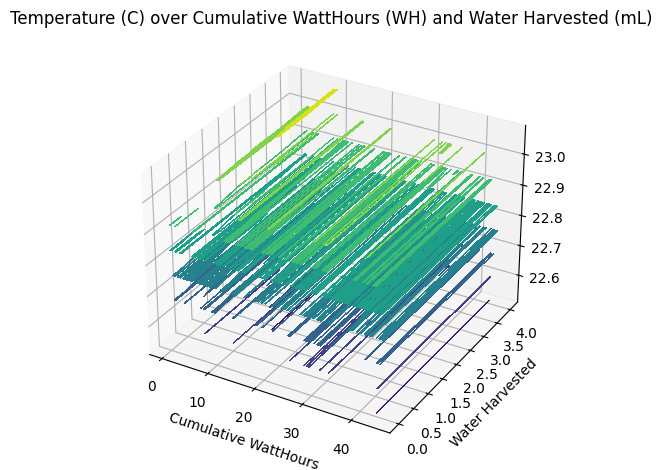

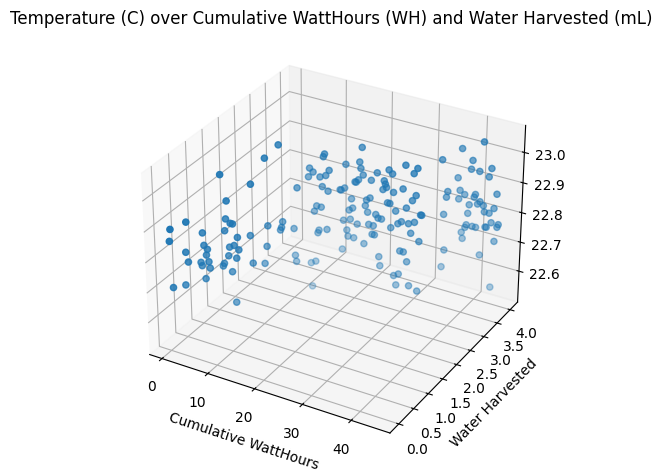

In [45]:
#Basic scatter plot
plt.plot(
    DC_x,
    DC_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = DepControl_Equations.equations_.query(
    f"loss < {2 * DepControl_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    DC_x,
    DepControl_Equations.predict(DC_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over Cumulative Watt Hours (WH)")
plt.xlabel("Average Cumulative Watt Hours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 50])
analysis(
    [
        pd.to_numeric(
            DepControl_Dataframe["WattHours (WH)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DC_z,
        pd.to_numeric(
            DepControl_Dataframe["Amps (A)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DC_y,
    ]
)
print(DepControl_Equations.latex())

#3D scatterplot and contour plot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours", loc="left")
plt.ylabel("Water Harvested")
fig.tight_layout()
DC_X, DC_Y = np.meshgrid(DC_x,DC_y)
DC_Z = sp.interpolate.griddata(np.column_stack((DC_x.reshape(-1,1),DC_y)), DC_z, (DC_X, DC_Y), method = "nearest")
plt.contourf(DC_x.reshape(-1),DC_y,DC_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(DC_x,DC_y,DC_z)

In [31]:
#Run PySR
DepProto_Equations = PySRRegressor(
    **default_pysr_params,
)

#Fit an equation to the data
DepProto_Equations.fit(DP_x,DP_y)

C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:872: FutureWarning: variable_names is a data dependant parameter so should be passed when fit is called. Ignoring parameter; please pass variable_names during the call to fit instead.
  warnings.warn(
C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:1231: UserWarning: Note: Using a large maxsize for the equation search will be exponentially slower and use significant memory.
  warnings.warn(
C:\Users\JohnSi\AppData\Local\Programs\Python\Python312\Lib\site-packages\pysr\sr.py:65: UserWarning: You are using the `^` operator, but have not set up `constraints` for it. This may lead to overly complex expressions. One typical constraint is to use `constraints={..., '^': (-1, 1)}`, which will allow arbitrary-complexity base (-1) but only powers such as a constant or variable (1). For more tips, please see https://astroautomata.com/PySR/tuning/
  warnings.warn(
[ Info: Start


Expressions evaluated per second: 2.500e+05
Head worker occupation: 24.2%
Progress: 781 / 5000 total iterations (15.620%)
Hall of Fame:
---------------------------------------------------------------------------------------------------
Complexity  Loss       Score     Equation
2           6.219e-01  7.971e+00  y = log(x₀)
3           1.258e-01  1.598e+00  y = 0.073674 * x₀
4           1.168e-01  7.434e-02  y = 0.073023 * ceil(x₀)
5           3.373e-02  1.242e+00  y = (x₀ * 0.11665) ^ 0.75573
6           3.373e-02  8.941e-07  y = (0.11662 * x₀) ^ cos(0.71389)
7           3.307e-02  1.981e-02  y = ((0.10805 * x₀) + 0.10405) ^ 0.7802
8           3.241e-02  2.014e-02  y = log((1.1215 ^ x₀) + 0.1828) ^ 0.76242
9           3.035e-02  6.553e-02  y = (log(ceil(1.1713 ^ x₀)) ^ 0.68646) + -0.33028
10          2.832e-02  6.933e-02  y = ((x₀ + cos(x₀ * 0.19506)) * 0.11728) ^ 0.75356
11          2.497e-02  1.257e-01  y = log(cos(1.0702 ^ x₀) + (1.1255 ^ x₀)) ^ 0.75093
12          2.482e-02  6.297e

PySRRegressor.equations_ = [
	    pick     score                                           equation  \
	0         0.000000                                            log(x0)   
	1         1.598349                                    0.07367398 * x0   
	2         0.074337                              0.07302348 * ceil(x0)   
	3         1.241635                    (0.116608955 * x0) ^ 0.75586104   
	4         0.010043        ((x0 + 1.0874258) * 0.10714035) ^ 0.7824767   
	5         0.020567     log((1.1204599 ^ x0) + 0.18955873) ^ 0.7659334   
	6         0.097493  ((x0 * 0.11497136) ^ 0.7615869) + (0.54394907 ...   
	7         0.122578   log(cos(log(x0)) + (1.1290764 ^ x0)) ^ 0.7410495   
	8         0.041872  log(cos(1.0720503 ^ x0) + (1.1244711 ^ x0)) ^ ...   
	9         0.020895  log(0.9501041 + ((-0.23076297 * x0) + (1.14544...   
	10        0.031225  log((cos(1.07183 ^ x0) * 1.5847301) + (1.12744...   
	11        0.011641  log((cos(1.0704453 ^ ceil(x0)) * 1.5536531) + ...   
	12        0.064381  log((cos(1.0701106 ^ x0) * (1.0707226 ^ x0)) +...   
	13        0.031373  log((1.125585 ^ (cos(x0 * -0.30061764) + x0)) ...   
	14        0.006115  log((1.125585 ^ (cos(floor(x0) * -0.30061764) ...   
	15        0.005612  log(cos(1.069367 ^ x0) + (1.131289 ^ floor(x0 ...   
	16        0.037432  log(cos(1.0716907 ^ x0) + (1.1308708 ^ floor(x...   
	17        0.020209  log(cos(1.0716907 ^ x0) + (1.1308708 ^ floor(c...   
	18        0.000839  log((erf(cos(1.0659151 ^ ceil(cos(x0) + (0.719...   
	19        0.019281  log(cos(1.0668814 ^ x0) + (1.1311268 ^ floor(x...   
	20        0.000671  log((erf(cos(1.0659151 ^ ceil(cos(x0) + (0.719...   
	21        0.012078  log((erf(cos(1.0659151 ^ ceil(cos(x0 + 0.77125...   
	22        0.004160  log((1.1373271 ^ x0) + (erf(cos(1.0666473 ^ ce...   
	23        0.006006  log(cos(1.0681947 ^ x0) + (1.1292642 ^ floor(x...   
	24        0.004262  log(cos(1.0681947 ^ x0) + (1.1292642 ^ floor(x...   
	25        0.002826  log(cos(1.0681947 ^ x0) + (1.1292642 ^ floor(x...   
	26        0.002178  log(cos(1.0681947 ^ x0) + (1.1292642 ^ floor(x...   
	27        0.002214  log(cos(1.0681947 ^ x0) + (1.1292642 ^ floor(x...   
	28        0.000126  log((1.1373271 ^ x0) + ((1.0780586 ^ (exp(sin(...   
	29        0.004691  log((1.1373271 ^ x0) + ((1.0780586 ^ (ceil(exp...   
	30        0.010997  log((1.1373271 ^ x0) + ((1.0780586 ^ (ceil(exp...   
	31        0.000629  log((1.1373271 ^ x0) + ((1.0780586 ^ (exp((sin...   
	32  >>>>  0.000987  log((1.1373271 ^ x0) + ((1.0780586 ^ (exp((sin...   
	
	        loss  complexity  
	0   0.621868           2  
	1   0.125760           3  
	2   0.116751           4  
	3   0.033731           5  
	4   0.033060           7  
	5   0.032387           8  
	6   0.029378           9  
	7   0.025989          10  
	8   0.024924          11  
	9   0.024408          12  
	10  0.023658          13  
	11  0.023384          14  
	12  0.021926          15  
	13  0.021249          16  
	14  0.021119          17  
	15  0.021001          18  
	16  0.020229          19  
	17  0.019825          20  
	18  0.019742          25  
	19  0.019365          26  
	20  0.019352          27  
	21  0.019119          28  
	22  0.018961          30  
	23  0.018848          31  
	24  0.018767          32  
	25  0.018714          33  
	26  0.018592          36  
	27  0.018510          38  
	28  0.018508          39  
	29  0.018421          40  
	30  0.018220          41  
	31  0.018208          42  
	32  0.018190          43  
]

Vertical Power STDDEV: 0.014679880518742925
Vertical Power MEDIAN: 0.44
Vertical Power SKEW: -0.09197059749850972 

Vertical Temp STDDEV: 0.15856514246117498
Vertical Temp MEDIAN: 25.01
Vertical Temp SKEW: -0.0984512551837561 

Vertical Amp STDDEV: 0.21317526595982159
Vertical Amp MEDIAN: 6.61
Vertical Amp SKEW: -0.07791209416425922 

Vertical Water STDDEV: 1.4485566224712627
Vertical Water MEDIAN: 3.33
Vertical Water SKEW: -0.2322940059788474 

\log{\left(1.08^{x_{0} + 2.39 e^{\sin{\left(x_{0} + 0.573 \right)}}} \operatorname{erf}{\left(\sin{\left(\operatorname{erf}{\left(\cos{\left(1.07^{\left\lceil{x_{0} + 1.00 \cos{\left(x_{0} + 0.771 \right)} + 0.349}\right\rceil} \right)} \right)} \right)} \right)} + 1.14^{x_{0}} \right)}^{0.720}


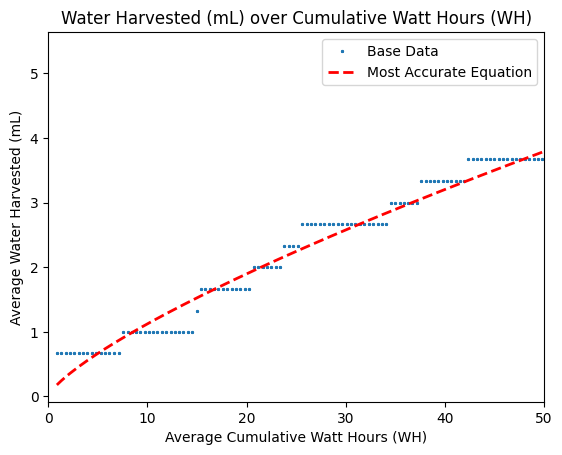

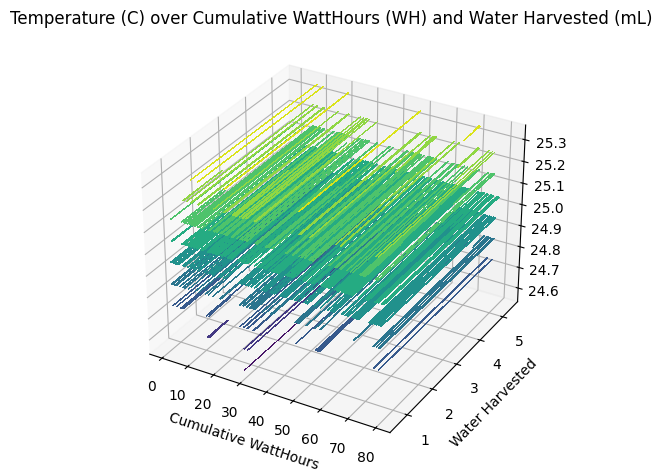

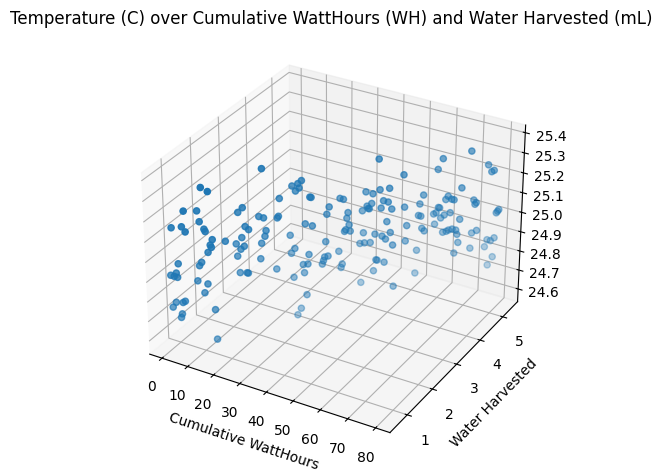

In [56]:
#Basic scatter plot
plt.plot(
    DP_x,
    DP_y,
    linewidth=2,
    linestyle="none",
    marker="*",
    label="Base Data",
    fillstyle="none",
    markersize=2,
)

#Fit the equation to the data
best_idx = DepProto_Equations.equations_.query(
    f"loss < {2 * DepProto_Equations.equations_.loss.min()}"
).score.idxmax()
plt.plot(
    DP_x,
    DepProto_Equations.predict(DP_x, index=best_idx),
    color="red",
    linestyle="dashed",
    linewidth=2,
    label="Most Accurate Equation",
)
plt.title("Water Harvested (mL) over Cumulative Watt Hours (WH)")
plt.xlabel("Average Cumulative Watt Hours (WH)")
plt.ylabel("Average Water Harvested (mL)")
plt.legend()
plt.xlim([0, 50])
analysis(
    [
        pd.to_numeric(
            DepProto_Dataframe["WattHours (WH)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DP_z,
        pd.to_numeric(
            DepProto_Dataframe["Amps (A)"].str.replace(
                r"[^0-9\.\-\+]", "", regex=True
            )
        ).to_numpy(),
        DP_y,
    ]
)
print(DepProto_Equations.latex())

#3D scatterplot
fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours", loc="left")
plt.ylabel("Water Harvested")
fig.tight_layout()
DP_X, DP_Y = np.meshgrid(DP_x,DP_y)
DP_Z = sp.interpolate.griddata(np.column_stack((DP_x.reshape(-1,1),DP_y)), DP_z, (DP_X, DP_Y), method = "nearest")
plt.contourf(DP_x.reshape(-1),DP_y,DP_Z)

fig = plt.figure()
ax = plt.axes(projection="3d")
plt.title("Temperature (C) over Cumulative WattHours (WH) and Water Harvested (mL)")
plt.xlabel("Cumulative WattHours")
plt.ylabel("Water Harvested")
fig.tight_layout()
ax.scatter3D(DP_x,DP_y,DP_z)